Found 3134 images belonging to 8 classes.
Found 778 images belonging to 8 classes.
Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 820s 17s/step - accuracy: 0.4807 - loss: 1.4180 - val_accuracy: 0.9165 - val_loss: 0.2959 - learning_rate: 1.0000e-04
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 817s 17s/step - accuracy: 0.8568 - loss: 0.4208 - val_accuracy: 0.9422 - val_loss: 0.1924 - learning_rate: 1.0000e-04
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 812s 17s/step - accuracy: 0.8925 - loss: 0.2909 - val_accuracy: 0.9486 - val_loss: 0.1488 - learning_rate: 1.0000e-04
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 790s 16s/step - accuracy: 0.9353 - loss: 0.2036 - val_accuracy: 0.9769 - val_loss: 0.0910 - learning_rate: 1.0000e-04
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 887s 18s/step - accuracy: 0.9375 - loss: 0.1652 - val_accuracy: 0.9717 - val_loss: 0.0850 - learning_rate: 1.0000e-04
13/13 ━━━━━━━━━━━━━━━━━━━━ 197s 15s/step - accuracy: 0.9612 - loss: 0.1041
Validation Loss: 0.09114114940166473
Validation Accuracy: 0.9691516

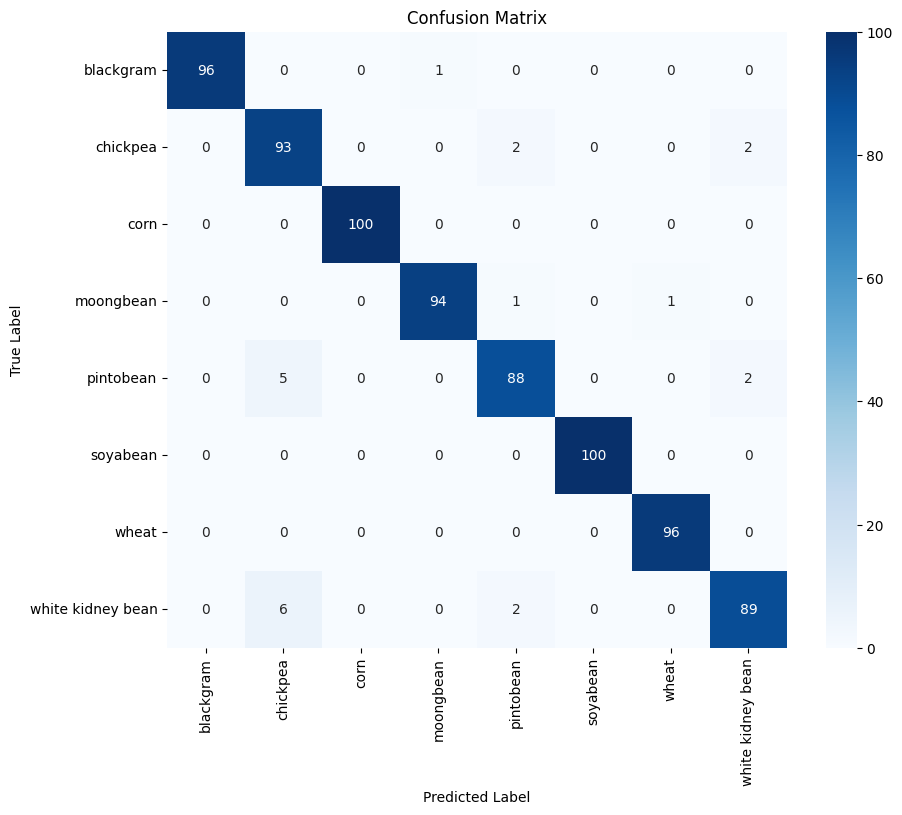

Classification Report:
                   precision    recall  f1-score   support

        blackgram       1.00      0.99      0.99        97
         chickpea       0.89      0.96      0.93        97
             corn       1.00      1.00      1.00       100
        moongbean       0.99      0.98      0.98        96
        pintobean       0.95      0.93      0.94        95
         soyabean       1.00      1.00      1.00       100
            wheat       0.99      1.00      0.99        96
white kidney bean       0.96      0.92      0.94        97

         accuracy                           0.97       778
        macro avg       0.97      0.97      0.97       778
     weighted avg       0.97      0.97      0.97       778



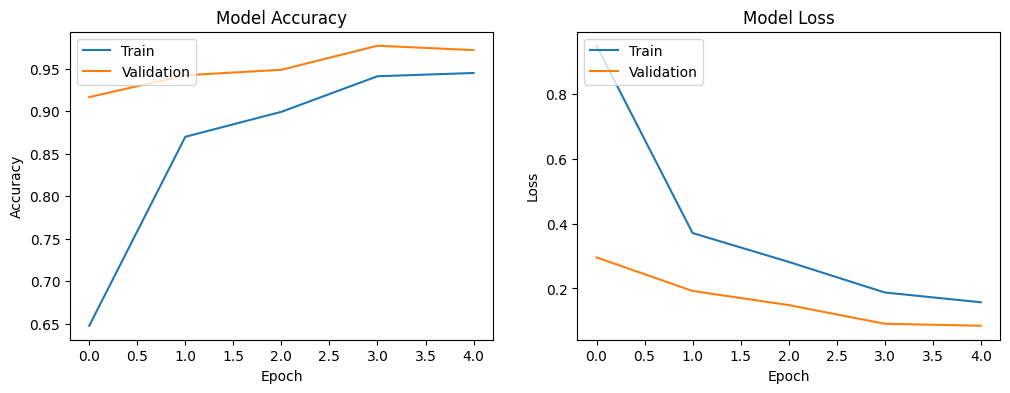

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step


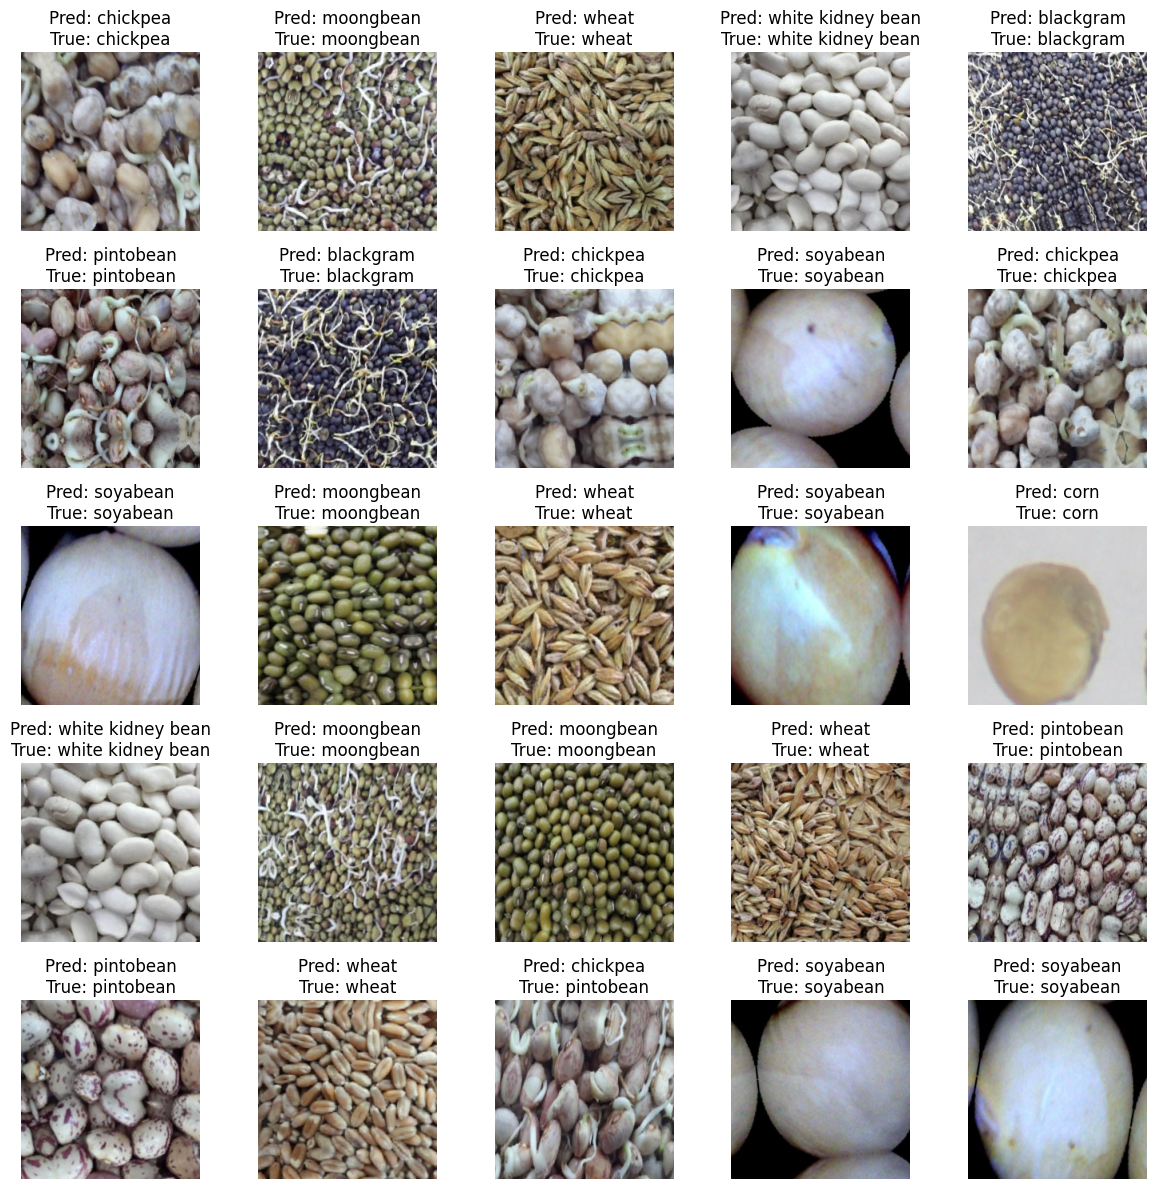

13/13 ━━━━━━━━━━━━━━━━━━━━ 162s 12s/step - accuracy: 0.9769 - loss: 0.0896
Test Accuracy: 0.9756


In [2]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# **VGG16 Model**
def build_vgg16(input_shape, num_classes):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model layers
    for layer in base_model.layers:
        layer.trainable = False
    
    x = Flatten()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# **Data Preparation**
dataset_dir = 'C:/Users/DELL/OneDrive/Documents/majorProject/seedsBalanced'
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='reflect',
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

# **Build and Train the Model**
num_classes = len(train_gen.class_indices)
vgg16_model = build_vgg16(input_shape=(224, 224, 3), num_classes=num_classes)

# Learning Rate Scheduler
def lr_scheduler(epoch, lr):
    return lr * 0.9 if epoch >= 10 else lr

lr_callback = LearningRateScheduler(lr_scheduler)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
early_stopping = EarlyStopping(monitor='val_loss', patience=29, restore_best_weights=True)

history = vgg16_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[reduce_lr, early_stopping, lr_callback]
)

# **Evaluate Model**
val_loss, val_accuracy = vgg16_model.evaluate(val_gen)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

# **Confusion Matrix & Classification Report**
def evaluate_model(model, val_gen):
    y_true = []
    y_pred = []
    
    for i in range(len(val_gen)):
        img_batch, label_batch = val_gen[i]
        preds = model.predict(img_batch)
        y_true.extend(np.argmax(label_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_gen.class_indices.keys(), yticklabels=val_gen.class_indices.keys())
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=val_gen.class_indices.keys()))

evaluate_model(vgg16_model, val_gen)

# **Plot Training and Validation Accuracy and Loss**
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

# **Visualizing Predictions on Validation Data**
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.flatten()

class_labels = list(val_gen.class_indices.keys())

for i in range(25):
    img_batch, label_batch = next(val_gen)
    
    img = img_batch[0]
    label = label_batch[0]
    
    pred = vgg16_model.predict(np.expand_dims(img, axis=0))
    pred_label = class_labels[np.argmax(pred[0])]
    true_label = class_labels[np.argmax(label)]
    
    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# **Final Model Evaluation**
test_loss, test_acc = vgg16_model.evaluate(val_gen)
print(f"Test Accuracy: {test_acc:.4f}")


In [3]:
def compute_classwise_accuracy(model, val_gen):
    y_true = []
    y_pred = []
    
    for i in range(len(val_gen)):
        img_batch, label_batch = val_gen[i]
        preds = model.predict(img_batch)
        y_true.extend(np.argmax(label_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    
    report = classification_report(y_true, y_pred, target_names=val_gen.class_indices.keys(), output_dict=True)
    
    print("Class-wise Accuracy:")
    for class_name, metrics in report.items():
        if isinstance(metrics, dict):
            print(f"{class_name}: {metrics['precision'] * 100:.2f}%")

compute_classwise_accuracy(vgg16_model, val_gen)

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Class-wise Accuracy:
blackgram: 100.00%
chickpea: 88.79%
corn: 100.00%
moongbean: 100.00%
pintobean: 97.73%
soyabean: 100.00%
wheat: 100.00%
white kidney bean: 100.00%
macro avg: 98.31%
weighted avg: 98.32%


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


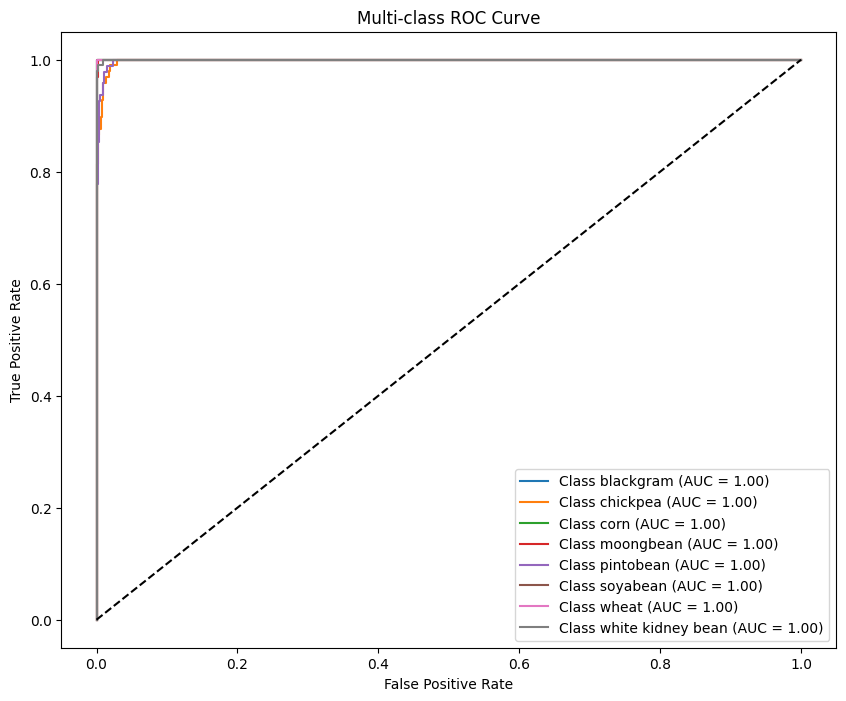

In [6]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Get the true labels and predicted probabilities
y_true = []
y_pred_prob = []

for i in range(len(val_gen)):
    img_batch, label_batch = val_gen[i]
    preds = vgg16_model.predict(img_batch)
    y_true.extend(np.argmax(label_batch, axis=1))  # Convert one-hot to labels
    y_pred_prob.extend(preds)  # Softmax probabilities

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Binarize the output labels
num_classes = len(val_gen.class_indices)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC Curve
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {list(val_gen.class_indices.keys())[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [7]:
from sklearn.metrics import cohen_kappa_score

# Get true labels and predicted labels
y_true = []
y_pred = []

for i in range(len(val_gen)):
    img_batch, label_batch = val_gen[i]
    preds = vgg16_model.predict(img_batch)
    y_true.extend(np.argmax(label_batch, axis=1))  # Convert one-hot to labels
    y_pred.extend(np.argmax(preds, axis=1))  # Get predicted class labels

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute Cohen’s Kappa Score
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Cohen's Kappa Score: 0.9838
